[2026-05-07 08:16:25 | +0.0s] ファイル検索開始
[2026-05-07 08:16:25 | +0.1s] 対象ファイル数: 4
[2026-05-07 08:16:25 | +0.1s] 処理中 (1/4): change_point_pairs_pelt_rbf_20260418_102306.csv


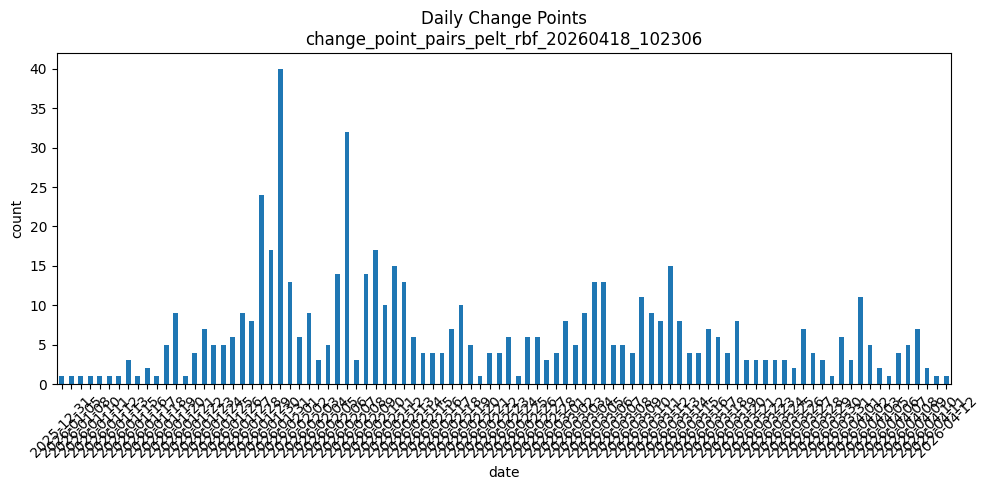

[2026-05-07 08:16:29 | +3.6s] 処理中 (2/4): change_point_pairs_pelt_l2_20260423_080337.csv


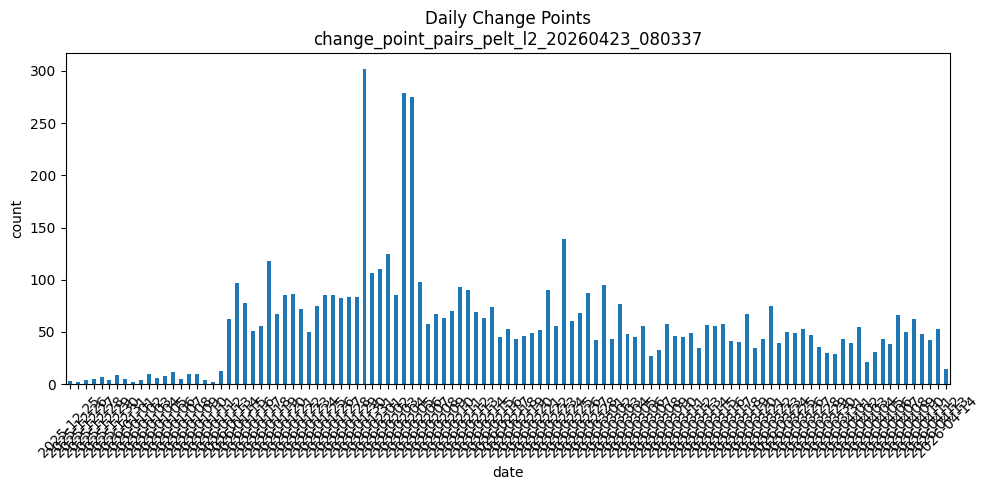

[2026-05-07 08:16:31 | +5.8s] 処理中 (3/4): change_point_pairs_Binseg_l1_20260424_163322.csv


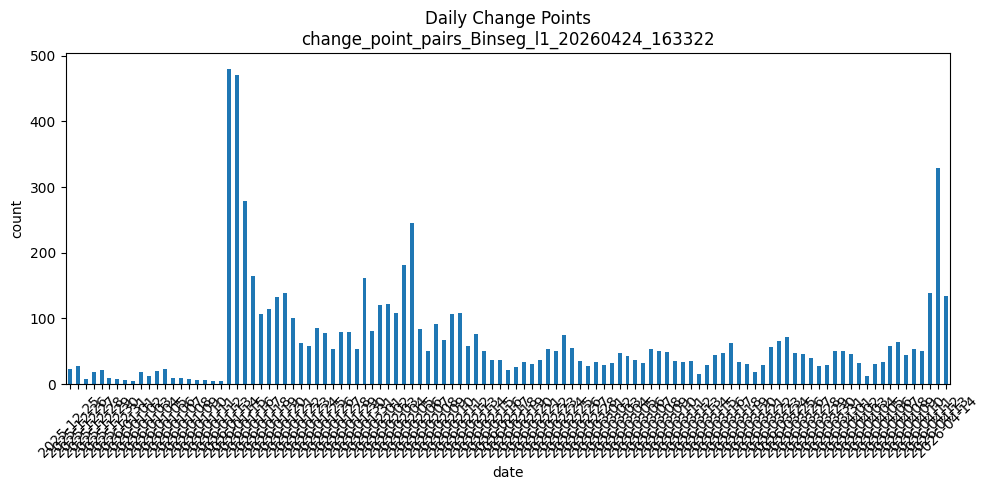

[2026-05-07 08:16:33 | +8.0s] 処理中 (4/4): change_point_pairs_ALL_METHODS_ALL_MODELS_20260504_001815.csv
[2026-05-07 08:16:33 | +8.0s] スキップ（データなし）: change_point_pairs_ALL_METHODS_ALL_MODELS_20260504_001815.csv
[2026-05-07 08:16:33 | +8.0s] 完了


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# =========================================
# 0. ログ関数
# =========================================
START_TIME = datetime.now()

def log(msg):
    now = datetime.now()
    elapsed = (now - START_TIME).total_seconds()
    print(f"[{now.strftime('%Y-%m-%d %H:%M:%S')} | +{elapsed:.1f}s] {msg}")

# =========================================
# 1. ファイル検索
# =========================================
log("ファイル検索開始")

current_dir = Path(".")
files = list(current_dir.glob("change_point_pairs_*.csv"))

if not files:
    raise FileNotFoundError("対象ファイルが見つかりません")

# 更新日時順
files = sorted(files, key=lambda f: f.stat().st_mtime)

log(f"対象ファイル数: {len(files)}")

# =========================================
# 2. ファイルごとに処理＆プロット
# =========================================
for i, file_path in enumerate(files):
    log(f"処理中 ({i+1}/{len(files)}): {file_path.name}")

    # -------------------------
    # 読み込み
    # -------------------------
    df = pd.read_csv(
        file_path,
        skiprows=1,
        names=["coin", "datetime", "score"]
    )

    # -------------------------
    # datetime変換
    # -------------------------
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    df = df.dropna(subset=["datetime"])

    if df.empty:
        log(f"スキップ（データなし）: {file_path.name}")
        continue

    # -------------------------
    # 集計
    # -------------------------
    df["date"] = df["datetime"].dt.date
    daily_counts = df.groupby("date").size().sort_index()

    # -------------------------
    # タイトル用
    # -------------------------
    file_name = file_path.stem
    if len(file_name) > 60:
        file_name = file_name[:60] + "..."

    # -------------------------
    # プロット
    # -------------------------
    plt.figure(figsize=(10, 5))

    daily_counts.plot(kind="bar")

    plt.xlabel("date")
    plt.ylabel("count")
    plt.title(f"Daily Change Points\n{file_name}")

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

log("完了")